In [7]:
from pathlib import Path
from obspy import read
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# How to read miniSEED files using ObsPy
# Define the dataset directory
data_dir = Path("data")

# Source: Finnish Seismic Network via GEOFON: 
# https://geofon.gfz.de/waveform/archive/network.php?ncode=HE
# Station Hetta (HEF) from 18th May 2020: 4.9 Magnitude earthquake near Kiruna, Sweden
path = data_dir / "HEF20200518.mseed"

# Read the filepath using ObsPy's read function
st = read(str(path))
print(st)

3 Trace(s) in Stream:
HE.HEF..HHZ | 2020-05-17T23:59:57.450000Z - 2020-05-19T00:00:01.980000Z | 100.0 Hz, 8640454 samples
HE.HEF..HHN | 2020-05-17T23:59:56.850000Z - 2020-05-18T23:59:59.900000Z | 100.0 Hz, 8640306 samples
HE.HEF..HHE | 2020-05-17T23:59:56.790000Z - 2020-05-19T00:00:01.100000Z | 100.0 Hz, 8640432 samples


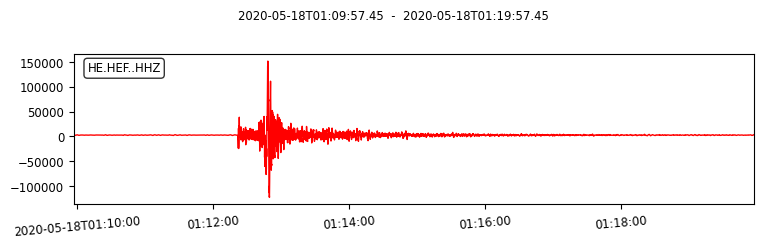

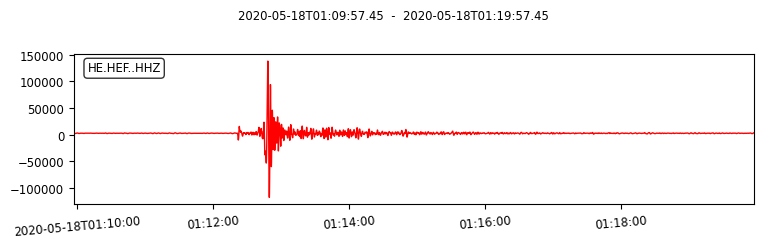

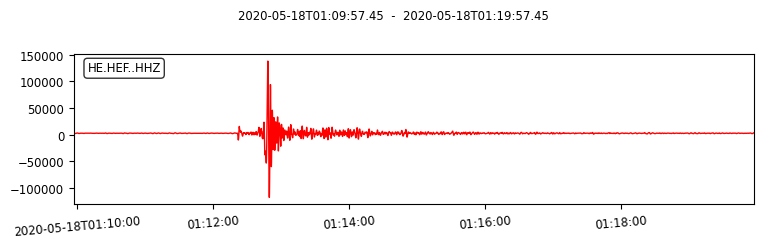

In [9]:
# Helper function for choosing the time of the trace
def add_time(dt, hours=0, minutes=0, seconds=0):
    return dt + hours * 3600 + minutes * 60 + seconds

# Taking only the first trace
tr = st[0]

# Filtering with a lowpass on a copy of the original Trace
# Options are bandpass, bandstop, lowpass and highpass
# Bandpass: Passes frequencies within a given range
# Bandstop: Blocks/attenuated frequences within a given range
# Lowpass/Highpass: Passes frequencies below/above a given frequency

# Copy the trace and filter it
tr_filt = tr.copy()
tr_filt.filter('lowpass', freq=1.0, corners=2, zerophase=True)

# Extract the time (UTC) when the trace starts
dt = tr.stats.starttime

# Choose which time of the trace to plot
start = add_time(dt, hours=1, minutes=10)
interval = add_time(start, minutes=10)

# Plot the original trace
tr.plot(color='red', tick_rotation=5, tick_format='%I:%M %p',
                   starttime=start, endtime=interval)

# Plot the filtered trace
tr_filt.plot(color='red', tick_rotation=5, tick_format='%I:%M %p',
                   starttime=start, endtime=interval)